In [1]:
import pandas as pd

In [3]:
dataset = pd.read_csv('watermelon-dataset.csv')
dataset

,ID,color,root,sound,texture,umbilicus,surface,density,sugar,ripe
0,1,green,curly,muffled,clear,hollow,hard,0.697,0.460,True
1,2,dark,curly,dull,clear,hollow,hard,0.774,0.376,True
2,3,dark,curly,muffled,clear,hollow,hard,0.634,0.264,True
3,4,green,curly,dull,clear,hollow,hard,0.608,0.318,True
4,5,light,curly,muffled,clear,hollow,hard,0.556,0.215,True
5,6,green,slightly curly,muffled,clear,slightly hollow,soft,0.403,0.237,True
6,7,dark,slightly curly,muffled,slightly blurry,slightly hollow,soft,0.481,0.149,True
7,8,dark,slightly curly,muffled,clear,slightly hollow,hard,0.437,0.211,True
8,9,dark,slightly curly,dull,slightly blurry,slightly hollow,hard,0.666,0.091,False
9,10,green,straight,crisp,clear,flat,soft,0.243,0.267,False


Il dataset Watermelon è eterogeneo in quanto presenta sia feature nominali che numeriche. Questa caratteristica richiede l'uso combinato di due varianti del teorema di Bayes per stimare le probabilità condizionate.

**1. Attributi Discreti (Categorical Naive Bayes)**
Per le variabili categoriche (come *color*, *root* o *sound*), la probabilità viene calcolata empiricamente tramite la frequenza relativa dei valori osservati (Eq. 7.17 in Screenshot 2026-09-01 alle 15.21.57.png):

$$P(x_i | c) = \frac{|D_{c,x_i}|}{|D_c|}$$

*   $c$: Specifica classe target da predire (es. anguria matura o acerba).
*   $x_i$: Valore assunto dall'$i$-esimo attributo discreto.
*   $|D_c|$: Numero totale di campioni nel training set che appartengono alla classe $c$.
*   $|D_{c,x_i}|$: Sottoinsieme di campioni della classe $c$ che presentano l'esatto valore $x_i$ per l'attributo in esame.

**Correzione di Laplace:**
Per scongiurare il problema della "probabilità zero" (che si verifica quando un valore non si è mai presentato per una determinata classe durante la fase di training), si applica una tecnica di *smoothing* richiesta dalle specifiche del modello:

$$P(x_i | c) = \frac{|D_{c,x_i}| + \alpha}{|D_c| + \alpha N_i}$$

*   $\alpha$: Pseudoconteggio o parametro di smoothing (per la correzione di Laplace, $\alpha = 1$).
*   $N_i$: Numero totale di categorie possibili assumibili dall'$i$-esimo attributo.

**2. Attributi Continui (Gaussian Naive Bayes)**
Per le variabili continue (come *density* e *sugar*), il modello assume che i valori seguano una distribuzione di probabilità Normale (Gaussiana) all'interno di ciascuna classe (Eq. 7.18 in Screenshot 2026-09-01 alle 15.21.57.png):

$$p(x_i | c) = \frac{1}{\sqrt{2\pi}\sigma_{c,i}} \exp\left(-\frac{(x_i - \mu_{c,i})^2}{2\sigma_{c,i}^2}\right)$$

*   $\mu_{c,i}$: Media aritmetica dell'$i$-esimo attributo continuo, calcolata esclusivamente sui campioni appartenenti alla classe $c$.
*   $\sigma_{c,i}^2$: Varianza dell'$i$-esimo attributo rispetto alla classe $c$, che modella la dispersione dei dati continui attorno alla media.

### 1. Use `CategoricalNB` and `GaussianNB` from `scikit-learn` to build a Naive Bayes classifier on the watermelon dataset. For the estimated probabilities, consider the Laplace correction techniques.


In [4]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB, GaussianNB

# Separazione delle feature in base al tipo di dato come da specifiche del dataset
cat_cols = ['color', 'root', 'sound', 'texture', 'umbilicus', 'surface'] #
num_cols = ['density', 'sugar'] #

X_cat = dataset[cat_cols]
X_num = dataset[num_cols]

# Conversione del target booleano (True/False) in intero (1/0)
y = dataset['ripe'].astype(int)

# CategoricalNB richiede array numerici: trasformiamo le stringhe in indici discreti
encoder = OrdinalEncoder()
X_cat_encoded = encoder.fit_transform(X_cat)

# 1. Addestramento del modello per gli attributi discreti
# Il parametro alpha=1.0 applica la Correzione di Laplace di default
cat_nb = CategoricalNB(alpha=1.0)
cat_nb.fit(X_cat_encoded, y)

# 2. Addestramento del modello per gli attributi continui
gauss_nb = GaussianNB()
gauss_nb.fit(X_num, y)

GaussianNB()

### 2. Using the previously trained model, predict the ripe/unripe class of the test example proposed by the book:
*ID=T1, color=green, root=curly, sound=muffled, texture=clear, umbilicous=hollow, surface=hard, density=0.697, sugar=0.460.*


In [5]:
# 1. Creazione del campione di test
test_example = pd.DataFrame({
    'color': ['green'],
    'root': ['curly'],
    'sound': ['muffled'],
    'texture': ['clear'],
    'umbilicus': ['hollow'],
    'surface': ['hard'],
    'density': [0.697],
    'sugar': [0.460]
})

# 2. Trasformazione dei dati utilizzando l'encoder precedente
X_test_cat = encoder.transform(test_example[cat_cols])
X_test_num = test_example[num_cols]

# 3. Estrazione delle probabilità calcolate dai due modelli
prob_cat = cat_nb.predict_proba(X_test_cat)
prob_num = gauss_nb.predict_proba(X_test_num)

# 4. Combinazione matematica delle probabilità
# predict_proba include già la probabilità a priori P(C).
# Per evitare di moltiplicarla due volte, dividiamo per il prior.
prior = np.exp(cat_nb.class_log_prior_)
joint_prob = (prob_cat * prob_num) / prior

# Normalizzazione per ottenere percentuali valide (somma = 1.0)
final_prob = joint_prob / np.sum(joint_prob, axis=1, keepdims=True)

# 5. Predizione della classe finale
predicted_class = np.argmax(final_prob, axis=1)[0]
is_ripe = "Ripe (True)" if predicted_class == 1 else "Unripe (False)"

print(f"Probabilità normalizzate [False, True]: {final_prob[0]}")
print(f"Predizione finale per il campione T1: {is_ripe}")

Probabilità normalizzate [False, True]: [0.00227783 0.99772217]
Predizione finale per il campione T1: Ripe (True)


### 3. Giving the dataset size, consider now an hold-out technique in which you draw randomly a single test example and you train the model on the remaining examples. Train both naive Bayes and decision trees.


In [8]:
from sklearn.model_selection import LeaveOneOut
from sklearn.tree import DecisionTreeClassifier

loo = LeaveOneOut()

# Liste per salvare i risultati di ogni iterazione (ci serviranno per i punti 4 e 5)
y_true_all = []
y_pred_nb_all = []
y_prob_nb_all = []
y_pred_dt_all = []
y_prob_dt_all = []

# Prepariamo gli array numpy per facilitare lo slicing nel ciclo
X_cat_encoded = encoder.fit_transform(X_cat)
X_num_np = X_num.values
y_np = y.values

# Uniamo le feature per il Decision Tree
X_combined = np.hstack([X_cat_encoded, X_num_np])

# Inizializziamo il Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Ciclo Leave-One-Out: itererà esattamente 17 volte
for train_index, test_index in loo.split(X_combined):
    # Slicing dei dati di addestramento e test
    X_cat_train, X_cat_test = X_cat_encoded[train_index], X_cat_encoded[test_index]
    X_num_train, X_num_test = X_num_np[train_index], X_num_np[test_index]
    X_comb_train, X_comb_test = X_combined[train_index], X_combined[test_index]
    y_train, y_test = y_np[train_index], y_np[test_index]

    # --- 1. Modello Naive Bayes Ibrido ---
    cat_nb = CategoricalNB(alpha=1.0)
    gauss_nb = GaussianNB()

    cat_nb.fit(X_cat_train, y_train)
    gauss_nb.fit(X_num_train, y_train)

    prob_cat = cat_nb.predict_proba(X_cat_test)
    prob_num = gauss_nb.predict_proba(X_num_test)
    prior = np.exp(cat_nb.class_log_prior_)

    joint_prob = (prob_cat * prob_num) / prior
    final_prob_nb = joint_prob / np.sum(joint_prob, axis=1, keepdims=True)

    y_prob_nb_all.append(final_prob_nb[0, 1])
    y_pred_nb_all.append(np.argmax(final_prob_nb, axis=1)[0])

    # --- 2. Modello Decision Tree ---
    dt.fit(X_comb_train, y_train)
    y_prob_dt_all.append(dt.predict_proba(X_comb_test)[0, 1])
    y_pred_dt_all.append(dt.predict(X_comb_test)[0])

    # Salvataggio del target reale
    y_true_all.append(y_test[0])

print("Validazione Leave-One-Out completata su 17 campioni.")

Validazione Leave-One-Out completata su 17 campioni.


### 4. Build the confusion matrix and the ROC curves for naive Bayes and decision trees.


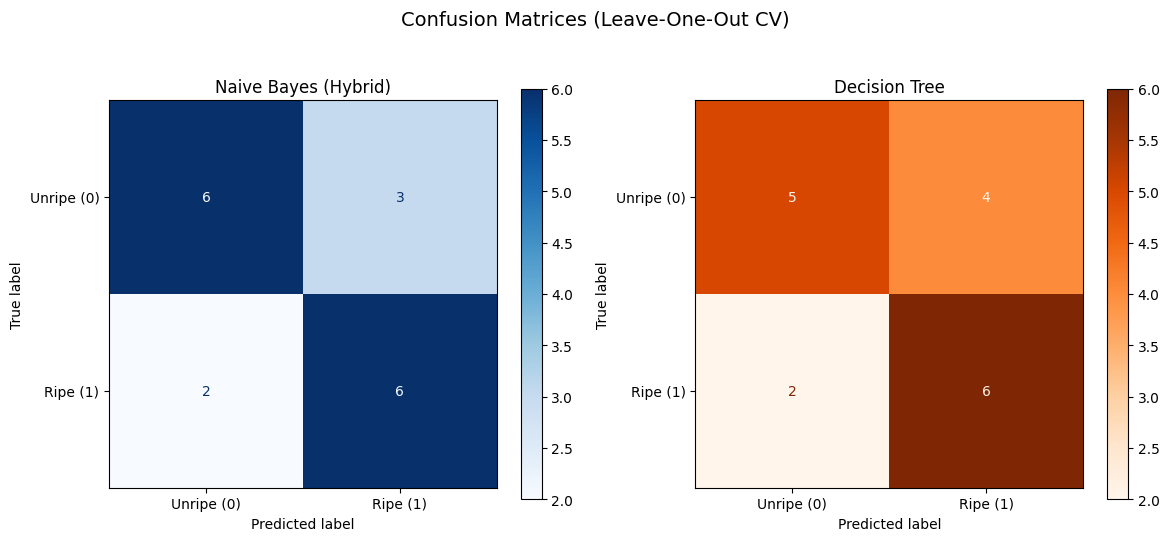

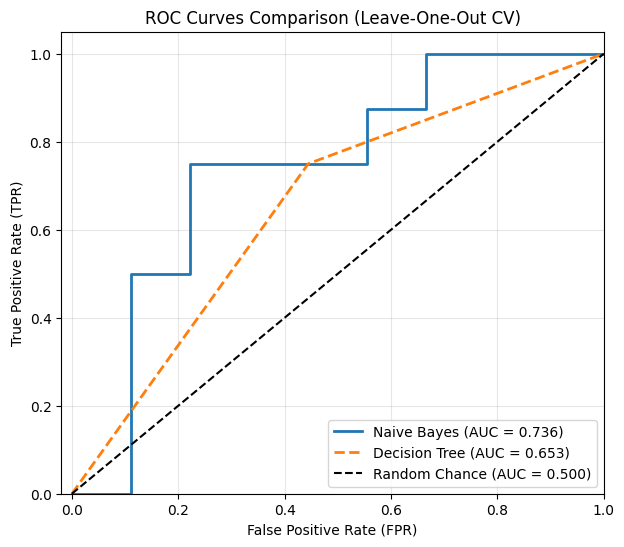

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# --- 1. Matrici di Confusione ---
cm_nb = confusion_matrix(y_true_all, y_pred_nb_all)
cm_dt = confusion_matrix(y_true_all, y_pred_dt_all)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices (Leave-One-Out CV)', fontsize=14, y=1.05)

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Unripe (0)', 'Ripe (1)'])
disp_nb.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[0])
axes[0].set_title('Naive Bayes (Hybrid)')

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Unripe (0)', 'Ripe (1)'])
disp_dt.plot(cmap=plt.cm.Oranges, values_format='d', ax=axes[1])
axes[1].set_title('Decision Tree')

plt.tight_layout()
plt.show()

# --- 2. Curve ROC ---
fpr_nb, tpr_nb, _ = roc_curve(y_true_all, y_prob_nb_all)
auc_nb = auc(fpr_nb, tpr_nb)

fpr_dt, tpr_dt, _ = roc_curve(y_true_all, y_prob_dt_all)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(7, 6))
plt.plot(fpr_nb, tpr_nb, color='#1f77b4', lw=2, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot(fpr_dt, tpr_dt, color='#ff7f0e', lw=2, linestyle='--', label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves Comparison (Leave-One-Out CV)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### 5. Implement statistical tests (e.g. `ttest_rel` in [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html)) to compare the naive Bayes models trained at 3. to Decision Trees on the same examples with an hold-out method. Have the observed differences in predictive performance statistical  significance?

In [10]:
from scipy.stats import ttest_rel

# 1. Vettorizzazione dei risultati: 1 per predizione corretta, 0 per errata
scores_nb = (np.array(y_pred_nb_all) == np.array(y_true_all)).astype(int)
scores_dt = (np.array(y_pred_dt_all) == np.array(y_true_all)).astype(int)

# 2. Esecuzione del Paired T-Test
t_stat, p_value = ttest_rel(scores_nb, scores_dt) #

# 3. Stampa delle metriche
print(f"Accuratezza Naive Bayes: {np.mean(scores_nb):.3f} ({np.sum(scores_nb)}/17 corrette)")
print(f"Accuratezza Decision Tree: {np.mean(scores_dt):.3f} ({np.sum(scores_dt)}/17 corrette)")
print(f"Statistica T: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# 4. Controllo della significatività con soglia alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print("\nRifiutiamo l'ipotesi nulla: la differenza di performance è statisticamente significativa.")
else:
    print("\nNon possiamo rifiutare l'ipotesi nulla: la differenza di performance NON è statisticamente significativa.")

Accuratezza Naive Bayes: 0.706 (12/17 corrette)
Accuratezza Decision Tree: 0.647 (11/17 corrette)
Statistica T: 0.566
P-value: 0.579

Non possiamo rifiutare l'ipotesi nulla: la differenza di performance NON è statisticamente significativa.
